In [4718]:
import numpy as np

# La boite générique

In [4719]:
class Boite():

  def __init__(self):
    pass

  def forward(self, inputs):
    self.inputs = inputs
    self.output = self.operation()
    return self.output

  def backward(self, derivee_output):
    assert derivee_output.shape == self.output.shape, f"La derivee_output reçue a un shape {derivee_output.shape} et different du shape de output : {self.output.shape}"

    self.derivee_inputs = self.gradient(derivee_output)
    assert self.derivee_inputs.shape == self.inputs.shape, f"La derivee_input calculée a un shape {self.derivee_inputs.shape } et different du shape de inputs : {self.inputs.shape}"

    return self.derivee_inputs


  def operation(self):
    pass

  def gradient(self, derivee_output):
    pass


# La boite paramètrée

In [4720]:
class BoiteParam():

  def __init__(self, param):
    self.param = param

  def forward(self, inputs):
    self.inputs = inputs
    self.output = self.operation()
    return self.output

  def backward(self, derivee_output):
    assert derivee_output.shape == self.output.shape, f"La derivee_output reçue a un shape {derivee_output.shape} et different du shape de output : {self.output}"

    self.derivee_inputs = self.gradient(derivee_output)
    assert self.derivee_inputs.shape == self.inputs.shape, f"La derivee_input calculée a un shape {self.derivee_inputs.shape } et different du shape de inputs : {self.inputs.shape}"

    self.derivee_param = self.gradient_param(derivee_output)
    assert self.derivee_param.shape == self.param.shape, f"La derivee de param a un shape {self.derivee_param.shape} et different du shape de param : {self.param.shape}"

    return self.derivee_inputs


  def operation(self):
    pass

  def gradient(self, derivee_output):
    pass


  def gradient_param(self, derivee_output):
    pass

# La classe Dot

In [4721]:
class Dot(BoiteParam):

  def __init__(self, weights):
    super().__init__(weights)

  def operation(self):
    return np.dot(self.inputs, self.param)

  def gradient(self, derivee_output):
    return np.dot( derivee_output, self.param.T)

  def gradient_param(self, derivee_output):
    return np.dot(self.inputs.T, derivee_output)

  def __repr__(self):
    return "DotProduct"

In [4722]:
X = np.array([[ 2,  3, -2],
       [ 4,  5, -1],
       [-5,  2,  3],
       [ 0,  5,  4]])

In [4723]:
X.shape

(4, 3)

In [4724]:
W = np.array([[ 0.49671415],
 [-0.1382643 ],
 [ 0.64768854]])
W.shape

(3, 1)

In [4725]:
np.dot(X, W)

array([[-0.71674168],
       [ 0.64784656],
       [-0.81703373],
       [ 1.89943266]])

In [4726]:
M = Dot(weights=W)
out = M.forward(X)
out

array([[-0.71674168],
       [ 0.64784656],
       [-0.81703373],
       [ 1.89943266]])

In [4727]:
M

DotProduct

In [4728]:
d_out = np.random.randn(4, 1)
d_out

array([[-1.72491783],
       [-0.56228753],
       [-1.01283112],
       [ 0.31424733]])

In [4729]:
M.backward(d_out)

array([[-0.85679109,  0.23849456, -1.11720951],
       [-0.27929617,  0.07774429, -0.36418719],
       [-0.50308755,  0.14003839, -0.65599911],
       [ 0.1560911 , -0.04344919,  0.2035344 ]])

# La classe Add

In [4730]:
class Add(BoiteParam):

  def __init__(self, biais):
    super().__init__(biais)

  def operation(self):
    return self.inputs + self.param

  def gradient(self, derivee_output):
    return np.ones_like(self.inputs) * derivee_output

  def gradient_param(self, derivee_output):
    r =  np.ones_like(self.param) * derivee_output
    return r.sum(axis=0).reshape(1, self.param.shape[1])

  def __repr__(self):
    return "AddBiais"

In [4731]:

B = np.random.rand(1, 1)
B

array([[0.29214465]])

In [4732]:
b = Add(biais=B)
b

AddBiais

In [4733]:
out_b = b.forward(out)
out_b

array([[-0.42459703],
       [ 0.93999121],
       [-0.52488908],
       [ 2.19157731]])

In [4734]:
d_out

array([[-1.72491783],
       [-0.56228753],
       [-1.01283112],
       [ 0.31424733]])

In [4735]:
b.backward(d_out)

array([[-1.72491783],
       [-0.56228753],
       [-1.01283112],
       [ 0.31424733]])

# La classe Sigmoid

In [4736]:
class Sigmoid(Boite):

  def __init__(self):
    super().__init__()

  def operation(self):
    return 1 / (1 + np.exp(-1 * self.inputs))

  def gradient(self, derivee_output):
    return self.output * (1 - self.output) * derivee_output

  def __repr__(self):
    return "Sigmoid"

In [4737]:
sig = Sigmoid()

In [4738]:
sig_out = sig.forward(out_b)
sig_out

array([[0.39541725],
       [0.71909788],
       [0.37170972],
       [0.8994906 ]])

In [4739]:
sig.backward(d_out)

array([[-0.41236308],
       [-0.1135799 ],
       [-0.2365382 ],
       [ 0.02841024]])

# La classe Loss

In [4740]:
class Loss():

  def __init__(self):
    pass

  def forward(self, prediction, target):
    assert prediction.shape == target.shape, f"Prediction shape {prediction.shape}  Target shape {target.shape}"
    self.prediction = prediction
    self.target = target
    loss = np.mean((self.target - self.prediction) ** 2)
    return loss

  def backward(self):

    self.loss_derivee = -2 * (self.target - self.prediction)
    assert self.loss_derivee.shape == self.prediction.shape, f"La derivee du loss un shape {self.loss_derivee.shape } et different du shape de Prediction : {self.prediction.shape}"

    return self.loss_derivee






In [4741]:
X

array([[ 2,  3, -2],
       [ 4,  5, -1],
       [-5,  2,  3],
       [ 0,  5,  4]])

In [4742]:
Y = np.random.randn(4, 1)
Y

array([[-0.7033438 ],
       [-2.13962066],
       [-0.62947496],
       [ 0.59772047]])

In [4743]:
P = sig_out

In [4744]:
mse = Loss()

In [4745]:
mse.forward(P, Y)

np.float64(2.618245871113618)

In [4746]:
mse.backward()

array([[2.1975221 ],
       [5.71743708],
       [2.00236935],
       [0.60354026]])

# La Classe Dense

In [4747]:
class Dense():

  def __init__(self, neurons, activation=None):
    self.neurons = neurons
    self.activation = activation
    self.params = []
    self.suite = []
    self.initialisation = True


  def build(self, inputs):
    # weights initialization
    np.random.seed(42)

    self.weights = np.random.randn(inputs.shape[1], self.neurons)
    self.biais = np.random.randn(1, self.neurons)

    self.params.append(self.weights)
    self.params.append(self.biais)

    # construction de la suite d'opération
    self.suite = [Dot(weights=self.params[0]), Add(biais=self.params[1])]
    if self.activation:
      self.suite.append(self.activation)


  def forward(self, inputs):
    if self.initialisation:
      self.build(inputs)
      self.initialisation = False

    for boite in self.suite:
      inputs = boite.forward(inputs)

    self.output = inputs

    return self.output


  def backward(self, derivee_output):
    assert derivee_output.shape == self.output.shape

    for boite in reversed(self.suite):
      derivee_output = boite.backward(derivee_output)

    derivee_inputs = derivee_output

    self.get_layer_gradients()

    return derivee_inputs


  def get_layer_gradients(self):

    self.derivee_params = []

    for boite in self.suite:
      if issubclass(boite.__class__, BoiteParam):
        self.derivee_params.append(boite.derivee_param)


  def __repr__(self):
    r = f"DenseLayer(neurons={self.neurons})"
    if self.activation:
      r += " avec Sigmoid"

    return r


In [4748]:
sigmoid = Sigmoid()

In [4749]:
couche = Dense(neurons=2, activation=sigmoid)

In [4750]:
couche

DenseLayer(neurons=2) avec Sigmoid

In [4751]:
X

array([[ 2,  3, -2],
       [ 4,  5, -1],
       [-5,  2,  3],
       [ 0,  5,  4]])

In [4752]:
couche.forward(X)

array([[0.99320003, 0.99604286],
       [0.99912347, 0.99968533],
       [0.42276305, 0.97817014],
       [0.97978765, 0.99941659]])

In [4753]:
couche.params

[array([[ 0.49671415, -0.1382643 ],
        [ 0.64768854,  1.52302986],
        [-0.23415337, -0.23413696]]),
 array([[1.57921282, 0.76743473]])]

In [4754]:
d_out = np.random.randn(4, 2)
d_out

array([[-0.46947439,  0.54256004],
       [-0.46341769, -0.46572975],
       [ 0.24196227, -1.91328024],
       [-1.72491783, -0.56228753]])

In [4755]:
couche.backward(d_out)

array([[-0.00187061,  0.00120335,  0.00024173],
       [-0.00018133, -0.00048599,  0.00012933],
       [ 0.03497832, -0.02397904, -0.00426045],
       [-0.0169224 , -0.02262434,  0.00807543]])

In [4756]:
couche.suite

[DotProduct, AddBiais, Sigmoid]

# La classe Model

In [4757]:
from copy import deepcopy

In [4758]:
class Model():

  def __init__(self, layers):
    self.layers = layers
    self.compiled = False
    self.learning_rate= 0.01


  def forward(self, inputs):

    for layer in self.layers:
      inputs = layer.forward(inputs)

    self.output = inputs
    return self.output


  def backward(self, loss_derivee):

    assert loss_derivee.shape == self.output.shape

    for layer in reversed(self.layers):
      loss_derivee = layer.backward(loss_derivee)

    return None

  def get_params(self):
    for layer in self.layers:
      yield from layer.params


  def get_derivee_params(self):
    for layer in self.layers:
      yield from layer.derivee_params


  def update(self):

    for (param, derivee_param) in zip(self.get_params(), self.get_derivee_params()):
      assert param.shape == derivee_param.shape
      param -=   self.learning_rate * derivee_param


  def compile(self, loss, learning_rate):
    self.loss = loss
    self.learning_rate = learning_rate
    self.compiled = True


  def fit(self, X, Y, epochs, validation_data=None):

    if validation_data:
      assert len(validation_data) == 2
      assert validation_data[0].shape[1] == X.shape[1]
      assert validation_data[1].shape[1] == Y.shape[1]

    self.history = {"loss":[]}
    if validation_data:
      self.history['val_loss'] = []


    if not self.compiled:
      raise NotImplementedError("Pas de loss et de learning_rate: Compilez")

    for epoch in range(epochs):
      # forward pass
      predictions = model.forward(X)
      loss = self.loss.forward(predictions, Y)
      self.history['loss'].append(loss)


      # val loss
      if validation_data:
        val_preds = model.forward(validation_data[0])
        val_loss = self.loss.forward(val_preds, validation_data[1])
        self.history['val_loss'].append(val_loss)

      log = f'Epoch {epoch+1:>5} .............. loss : {loss}'
      if validation_data:
        log += f"  ....val_loss : {val_loss}"
      print(log)


      # backward pass
      loss_derivee = self.loss.backward()
      self.backward(loss_derivee)

      # update
      self.update()

    return self.history

  def save_model(self, file):
    model_save = deepcopy(self)

    import pickle
    with open(file, "wb") as f:
      pickle.dump(model_save, f)


  def __repr__(self):

    r = "Layers ................."
    for layer in self.layers:
      r += f" \n - {str(layer)}"

    return r




In [4759]:
model = Model(layers = [ Dense(neurons=3, activation=sigmoid),
       Dense(neurons=1)])

In [4760]:
model

Layers ................. 
 - DenseLayer(neurons=3) avec Sigmoid 
 - DenseLayer(neurons=1)

In [4761]:
X

array([[ 2,  3, -2],
       [ 4,  5, -1],
       [-5,  2,  3],
       [ 0,  5,  4]])

In [4762]:
Y

array([[-0.7033438 ],
       [-2.13962066],
       [-0.62947496],
       [ 0.59772047]])

In [4763]:
model.forward(X)

array([[2.47005633],
       [2.53479834],
       [1.89807891],
       [1.92678186]])

In [4764]:
loss_derivee = np.random.randn(4, 1)
loss_derivee

array([[-0.23415337],
       [-0.23413696],
       [ 1.57921282],
       [ 0.76743473]])

In [4765]:
model.backward(loss_derivee)

In [4766]:
model.get_params()

<generator object Model.get_params at 0x7bcf3f46a260>

In [4767]:
model.get_derivee_params()

<generator object Model.get_derivee_params at 0x7bcf3f26ec20>

# Update des paramètres

In [4768]:
M


DotProduct

In [4769]:
M.__class__, issubclass(M.__class__, BoiteParam)

(__main__.Dot, True)

In [4770]:
M.__class__

__main__.Dot

In [4771]:
M.param

array([[ 0.49671415],
       [-0.1382643 ],
       [ 0.64768854]])

In [4772]:
M.derivee_inputs

array([[-0.85679109,  0.23849456, -1.11720951],
       [-0.27929617,  0.07774429, -0.36418719],
       [-0.50308755,  0.14003839, -0.65599911],
       [ 0.1560911 , -0.04344919,  0.2035344 ]])

In [4773]:
couche.params # [ [W], [B]]

[array([[ 0.49671415, -0.1382643 ],
        [ 0.64768854,  1.52302986],
        [-0.23415337, -0.23413696]]),
 array([[1.57921282, 0.76743473]])]

In [4774]:
couche.derivee_params

[array([[-0.30320043,  0.20796531],
        [-0.06424681, -0.07766607],
        [ 0.04724885, -0.1280065 ]]),
 array([[ 0.02131064, -0.03919074]])]

In [4775]:
for p, dp in zip([1,2,3], [4,5,6]):
  print(p, dp)

1 4
2 5
3 6


In [4776]:
def gen():
  for i in range(10):
    yield i

g = gen() # Ainsi, nous ne créons pas un nouveau generator à chaque appel de next()
print (next(g))
print (next(g))
print (next(g))

0
1
2


In [4777]:
X1 = X
Y1 = Y
model1 = Model(layers = [ Dense(neurons=2, activation=sigmoid),
       Dense(neurons=1)])
#forward
P1 = model1.forward(X1)
mse1 = Loss()
loss1 = mse1.forward(P1, Y1)
print(loss1)
#backward
loss_derivee1 = mse1.backward()
model1.backward(loss_derivee1)

3.6981060855841332


In [4778]:
model1.update()
P1 = model1.forward(X1)
mse1 = Loss()
loss1 = mse.forward(P1, Y1)
print(loss1)
# À relancer pour améliorer le loss

2.619935654638198


In [4779]:
P

array([[0.39541725],
       [0.71909788],
       [0.37170972],
       [0.8994906 ]])

In [4780]:
X

array([[ 2,  3, -2],
       [ 4,  5, -1],
       [-5,  2,  3],
       [ 0,  5,  4]])

In [4781]:
model1.forward(X)

array([[0.62534503],
       [0.62656276],
       [0.40111736],
       [0.61863384]])

In [4782]:
model1.layers[1].params

[array([[ 0.38072217],
        [-0.2695623 ]]),
 array([[0.51564079]])]

# Test de la fonction fit

In [4783]:
model = Model(layers = [ Dense(neurons=2, activation=sigmoid),
       Dense(neurons=1)])
mse = Loss()
model.compile(loss=mse, learning_rate=0.01)
h = model.fit(X, Y, epochs=10)


Epoch     1 .............. loss : 3.6981060855841332
Epoch     2 .............. loss : 2.619935654638198
Epoch     3 .............. loss : 1.9672429216211014
Epoch     4 .............. loss : 1.5692455053362315
Epoch     5 .............. loss : 1.3256063394627393
Epoch     6 .............. loss : 1.176141207030512
Epoch     7 .............. loss : 1.08434039010121
Epoch     8 .............. loss : 1.027918280626821
Epoch     9 .............. loss : 0.993225105612725
Epoch    10 .............. loss : 0.971884780439954


# Comparaison Tensorflow

In [4784]:
# import tensorflow as tf
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense
# from tensorflow.keras.optimizers import SGD

# model = Sequential([Dense(units=2, activation='sigmoid'),
#                     Dense(units=1)])
# model.compile(optimizer=SGD(learning_rate=0.1), loss='mse')
# history = model.fit(X, Y, epochs=10)

In [4785]:
# ??Sequential

# Validation

In [4786]:
model = Model(layers = [ Dense(neurons=2, activation=sigmoid),
       Dense(neurons=1)])
mse = Loss()
model.compile(loss=mse, learning_rate=0.01)
h = model.fit(X, Y, epochs=10, validation_data=(X, Y))

Epoch     1 .............. loss : 3.6981060855841332  ....val_loss : 3.6981060855841332
Epoch     2 .............. loss : 2.619935654638198  ....val_loss : 2.619935654638198
Epoch     3 .............. loss : 1.9672429216211014  ....val_loss : 1.9672429216211014
Epoch     4 .............. loss : 1.5692455053362315  ....val_loss : 1.5692455053362315
Epoch     5 .............. loss : 1.3256063394627393  ....val_loss : 1.3256063394627393
Epoch     6 .............. loss : 1.176141207030512  ....val_loss : 1.176141207030512
Epoch     7 .............. loss : 1.08434039010121  ....val_loss : 1.08434039010121
Epoch     8 .............. loss : 1.027918280626821  ....val_loss : 1.027918280626821
Epoch     9 .............. loss : 0.993225105612725  ....val_loss : 0.993225105612725
Epoch    10 .............. loss : 0.971884780439954  ....val_loss : 0.971884780439954


# Test du code final sur le boston dataset

In [4787]:
import pandas as pd
import numpy as np

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]
data = data
target = target

X = data
Y = target.reshape((506, 1))

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.25, random_state=0)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [4788]:
X_train.shape, y_train.shape

((379, 13), (379, 1))

In [4789]:
X_test.shape, y_test.shape

((127, 13), (127, 1))

## Regression linéaire simple

In [4790]:
model = Model([ Dense(neurons=1)])
mse = Loss()
model.compile(loss=mse, learning_rate=0.001)
h = model.fit(X_train, y_train, epochs=30, validation_data=(X_test, y_test))

Epoch     1 .............. loss : 712.1743316753176  ....val_loss : 671.7547143671588
Epoch     2 .............. loss : 384.0837028693358  ....val_loss : 383.82786822291087
Epoch     3 .............. loss : 247.75414344252928  ....val_loss : 229.1941295737599
Epoch     4 .............. loss : 148.3806303920543  ....val_loss : 144.19534190777878
Epoch     5 .............. loss : 103.89520896898965  ....val_loss : 96.47739842280843
Epoch     6 .............. loss : 71.33479105168065  ....val_loss : 69.15302180485378
Epoch     7 .............. loss : 55.97937743045081  ....val_loss : 53.20253156199875
Epoch     8 .............. loss : 44.69041961018085  ....val_loss : 43.70966230146516
Epoch     9 .............. loss : 39.11541183660613  ....val_loss : 37.94536623883121
Epoch    10 .............. loss : 35.00552004305203  ....val_loss : 34.3691118394618
Epoch    11 .............. loss : 32.86685286102087  ....val_loss : 32.09754754821056
Epoch    12 .............. loss : 31.27998033095609

In [4791]:
h.keys(), "Les 5 premières valeurs:", {k: [int(x) for x in v[:5]] for k, v in h.items()}

(dict_keys(['loss', 'val_loss']),
 'Les 5 premières valeurs:',
 {'loss': [712, 384, 247, 148, 103], 'val_loss': [671, 383, 229, 144, 96]})

In [4792]:
import matplotlib.pyplot as plt

def plot_learning_curve(history):


  plt.plot(list(range(len(history['loss']))), history['loss'], label='loss')
  plt.plot(list(range(len(history['val_loss']))), history['val_loss'], label='val_loss')
  plt.xlabel('Epochs')
  plt.ylabel("Loss")
  plt.title("Learning Curve")
  plt.legend()
  plt.show()

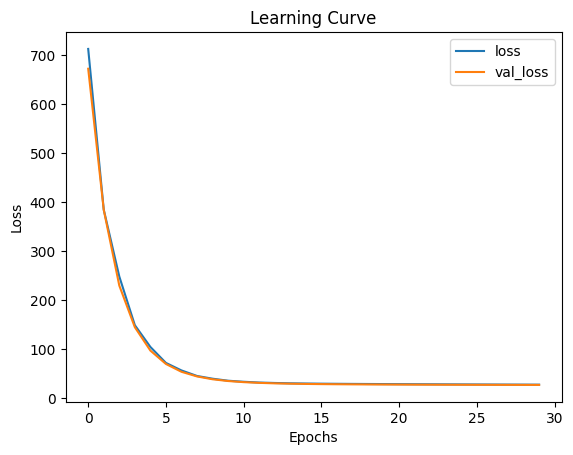

In [4793]:
plot_learning_curve(h)

## Réseau de neurones simple

In [4794]:
sigmoid = Sigmoid()
model = Model([ Dense(neurons=3, activation=sigmoid),
                Dense(neurons=1)
                ])

In [4795]:
model

Layers ................. 
 - DenseLayer(neurons=3) avec Sigmoid 
 - DenseLayer(neurons=1)

In [4796]:
mse = Loss()
model.compile(loss=mse, learning_rate=0.001)
h = model.fit(X_train, y_train, epochs=150, validation_data=(X_test, y_test))

Epoch     1 .............. loss : 507.9248956497336  ....val_loss : 492.311693850643
Epoch     2 .............. loss : 177.0600411831213  ....val_loss : 171.3573108990323
Epoch     3 .............. loss : 76.34310648866352  ....val_loss : 78.07141378521936
Epoch     4 .............. loss : 57.99769313037382  ....val_loss : 59.242268107160264
Epoch     5 .............. loss : 50.56069718790546  ....val_loss : 50.90120863498075
Epoch     6 .............. loss : 48.02490989618047  ....val_loss : 48.056787955807145
Epoch     7 .............. loss : 45.24327508981344  ....val_loss : 45.71030307412673
Epoch     8 .............. loss : 43.266239214476165  ....val_loss : 43.64692480403692
Epoch     9 .............. loss : 40.86833734070721  ....val_loss : 41.40535134329987
Epoch    10 .............. loss : 39.365032286039344  ....val_loss : 39.387747894940226
Epoch    11 .............. loss : 38.714063481767425  ....val_loss : 37.85180504818935
Epoch    12 .............. loss : 37.205756273611

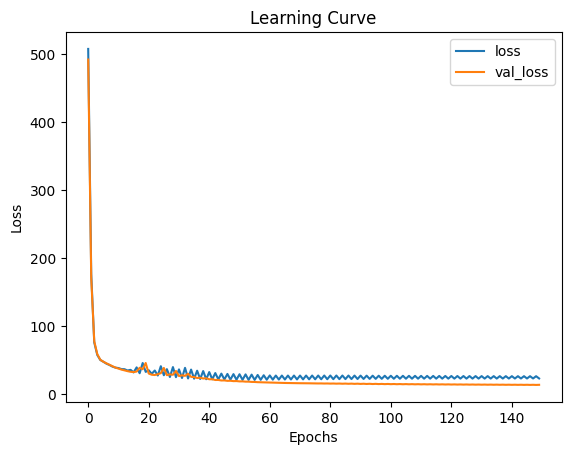

In [4797]:
plot_learning_curve(h)

## Deep Neural Network

In [4798]:
sigmoid = Sigmoid()
model = Model([ Dense(neurons=13, activation=sigmoid),
                Dense(neurons=1),
                ])

In [4799]:
model

Layers ................. 
 - DenseLayer(neurons=13) avec Sigmoid 
 - DenseLayer(neurons=1)

In [4800]:
mse = Loss()
model.compile(loss=mse, learning_rate=0.0001)
h = model.fit(X_train, y_train, epochs=150, validation_data=(X_test, y_test))

Epoch     1 .............. loss : 609.4535263872165  ....val_loss : 594.285047596059
Epoch     2 .............. loss : 494.7172454598782  ....val_loss : 479.0339597155269
Epoch     3 .............. loss : 403.8643944989146  ....val_loss : 388.125852443045
Epoch     4 .............. loss : 331.0559254119759  ....val_loss : 315.67394558965
Epoch     5 .............. loss : 272.44802631944543  ....val_loss : 257.80096535791387
Epoch     6 .............. loss : 225.32104126553727  ....val_loss : 211.7461595039089
Epoch     7 .............. loss : 187.60578616146617  ....val_loss : 175.37471756759948
Epoch     8 .............. loss : 157.62037539699094  ....val_loss : 146.91491099254424
Epoch     9 .............. loss : 133.9379615740088  ....val_loss : 124.84238208175846
Epoch    10 .............. loss : 115.33306807953525  ....val_loss : 107.84460906755527
Epoch    11 .............. loss : 100.76383198721742  ....val_loss : 94.8136613248053
Epoch    12 .............. loss : 89.36281102397

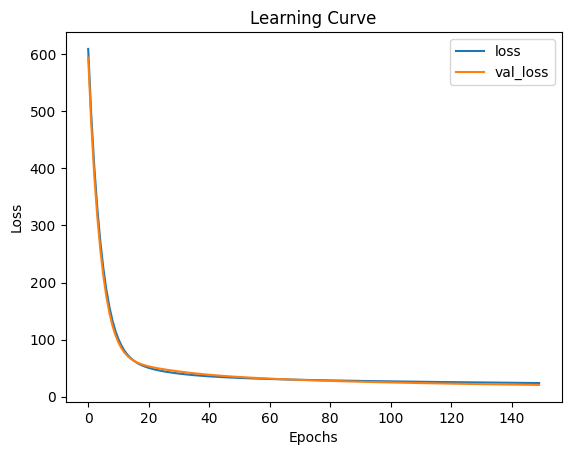

In [4801]:
plot_learning_curve(h)

# Sauvegarder le Modèle

In [4802]:
sigmoid = Sigmoid()
model = Model([ Dense(neurons=13, activation=sigmoid),
               Dense(neurons=1),

                ])

In [4803]:
mse = Loss()
model.compile(loss=mse, learning_rate=0.0001)
h = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Epoch     1 .............. loss : 609.4535263872165  ....val_loss : 594.285047596059
Epoch     2 .............. loss : 494.7172454598782  ....val_loss : 479.0339597155269
Epoch     3 .............. loss : 403.8643944989146  ....val_loss : 388.125852443045
Epoch     4 .............. loss : 331.0559254119759  ....val_loss : 315.67394558965
Epoch     5 .............. loss : 272.44802631944543  ....val_loss : 257.80096535791387
Epoch     6 .............. loss : 225.32104126553727  ....val_loss : 211.7461595039089
Epoch     7 .............. loss : 187.60578616146617  ....val_loss : 175.37471756759948
Epoch     8 .............. loss : 157.62037539699094  ....val_loss : 146.91491099254424
Epoch     9 .............. loss : 133.9379615740088  ....val_loss : 124.84238208175846
Epoch    10 .............. loss : 115.33306807953525  ....val_loss : 107.84460906755527


In [4804]:
model.save_model('model.file')

In [4805]:
import pickle

def load_model(file):
  with open(file, 'rb') as f:
    model_load = pickle.load(f)
  return model_load

In [4806]:
model_loaded = load_model("model.file")
model_loaded

Layers ................. 
 - DenseLayer(neurons=13) avec Sigmoid 
 - DenseLayer(neurons=1)